In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from resolve.utilities import utilities as utils
from resolve.hierarchically_conditioned_attentive_neural_process import DataGeneration, Normalizer
from resolve.hierarchically_conditioned_attentive_neural_process import HCTargetAttnLNP
from resolve.hierarchically_conditioned_attentive_neural_process import Trainer
from resolve.hierarchically_conditioned_attentive_neural_process.losses import AsymmetricFocalWithFPPenalty
from torch.utils.tensorboard import SummaryWriter
import yaml

In [2]:
# Set the path to the yaml settings file here
path_to_settings = "../"
with open(f"{path_to_settings}/settings.yaml", "r") as f:
    config_file = yaml.safe_load(f)

torch.manual_seed(0)
BATCH_SIZE = config_file["cnp_settings"]["batch_size_train"]

FILES_PER_BATCH = config_file["cnp_settings"]["files_per_batch_train"]
target_range = config_file["simulation_settings"]["target_range"]
is_binary = target_range[0] >= 0 and target_range[1] <= 1
version = config_file["path_settings"]["version"]
path_out = f'{config_file["path_settings"]["path_out_hcanp"]}/{version}'

In [3]:
x_size, y_size = utils.get_feature_and_label_size(config_file)

In [4]:
d_theta = len(config_file["simulation_settings"]["theta_headers"])
d_phi = len(config_file["simulation_settings"]["phi_labels"])
d_y = y_size
d_model = 128
model = HCTargetAttnLNP(d_theta, d_phi, d_y, d_model)

In [5]:
#model.load_state_dict(torch.load(f'{path_out}/cnp_{version}_model.pth'))
model.load_state_dict(torch.load("../out/hcacnp/v1.3.4/cnp_v1.3.4_model.pth"))
model.eval()

HCTargetAttnLNP(
  (ctx_enc): ContextConditionalEncoder(
    (theta_enc): ThetaEncoder(
      (mlp): MLP(
        (net): Sequential(
          (0): Linear(in_features=4, out_features=64, bias=True)
        )
      )
    )
    (feature_layers): ModuleList(
      (0): Linear(in_features=25, out_features=128, bias=True)
      (1): Linear(in_features=128, out_features=128, bias=True)
    )
    (film_layers): ModuleList(
      (0-1): 2 x Linear(in_features=64, out_features=256, bias=True)
    )
    (final): Identity()
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (post_q): LatentPosterior(
    (net): MLP(
      (net): Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=16, bias=True)
      )
    )
  )
  (latent_proj): LatentTokenProj(
    (to_token): MLP(
      (net): Sequential(
        (0): Linear(in_features=8, out_features=128, bias=True)
      )
    )
    (to_base):

In [6]:
model_fullname = model.__class__.__name__
print(model_fullname)

HCTargetAttnLNP


In [7]:
dataset_train = DataGeneration(mode = "train", 
                                config_file=config_file, 
                                path_to_files=config_file["path_settings"]["path_to_files_train"],
                                batch_size=BATCH_SIZE,
                                files_per_batch=FILES_PER_BATCH
                                )

normalizer = Normalizer(method=config_file["feature_settings"]["use_normalization"])
normalizer.fit_from_files(dataset_train.files, dataset_train.parameters)
print(normalizer.scaler.mean_)
print(normalizer.data_range_)

trainer = Trainer(model, dataset_train, normalizer)

trainer.criterion = AsymmetricFocalWithFPPenalty(
                dataset_train.signal_rate if config_file["cnp_settings"]["training"]["phase1"]["loss"]["prior_pos"]==True else 0.5,
                alpha_pos=config_file["cnp_settings"]["training"]["phase1"]["loss"]["alpha_pos"],
                alpha_neg=config_file["cnp_settings"]["training"]["phase1"]["loss"]["alpha_neg"],
                gamma_pos=config_file["cnp_settings"]["training"]["phase1"]["loss"]["gamma_pos"],
                gamma_neg=config_file["cnp_settings"]["training"]["phase1"]["loss"]["gamma_neg"],
                lambda_fp=config_file["cnp_settings"]["training"]["phase1"]["loss"]["lambda_fp"],
                tau_fp=config_file["cnp_settings"]["training"]["phase1"]["loss"]["tau_fp"],
                reduction=config_file["cnp_settings"]["training"]["phase1"]["loss"]["reduction"]
            )

Data Processing in Progress: 100%|██████████| 778/778 [00:01<00:00, 661.09it/s]


Overall signal rate in training data: [0.00734404]


Computing global feature stats: 100%|██████████| 778/778 [00:05<00:00, 145.55it/s]

[1.50348715e-02 5.00129305e+00 5.00550129e+02 4.97897172e+02
 0.00000000e+00 0.00000000e+00 0.00000000e+00 3.11915167e-02
 1.38558689e+01 7.50336709e+01 3.83881662e+01 1.93175236e-01
 0.00000000e+00 1.50348715e-02 1.50348715e-02 0.00000000e+00
 0.00000000e+00 5.00129305e+00 1.50000000e+00 3.00000000e+01
 3.00000000e+01 1.00000000e+00 5.03476519e-01 1.08869150e+02
 1.17400428e+01 1.10084019e+01 1.00000000e+00 9.90905313e-01]
[2.98700000e-02 9.98286000e+00 9.99000000e+02 9.97000000e+02
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e+00
 1.40000000e+01 1.46810038e+02 1.49426773e+02 1.00000000e+00
 0.00000000e+00 2.98700000e-02 2.98700000e-02 0.00000000e+00
 0.00000000e+00 9.98286000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 9.99984721e-01 9.99824189e+02
 1.40000000e+01 1.50000000e+01 0.00000000e+00 1.00000000e+00]


In [8]:
normalizer.data_range_

array([2.98700000e-02, 9.98286000e+00, 9.99000000e+02, 9.97000000e+02,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
       1.40000000e+01, 1.46810038e+02, 1.49426773e+02, 1.00000000e+00,
       0.00000000e+00, 2.98700000e-02, 2.98700000e-02, 0.00000000e+00,
       0.00000000e+00, 9.98286000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 9.99984721e-01, 9.99824189e+02,
       1.40000000e+01, 1.50000000e+01, 0.00000000e+00, 1.00000000e+00])

In [9]:
writer = SummaryWriter(log_dir=f'{path_out}/cnp_{version}_tensorboard_logs_prediction')

In [10]:


dataset_test = DataGeneration(mode = "test", 
                                    config_file=config_file, 
                                    path_to_files=config_file["path_settings"]["path_to_files_train"],
                                    batch_size=BATCH_SIZE,
                                    files_per_batch=1)

trainer.predict(dataset_test)




Processing files:   0%|          | 2/778 [00:05<28:27,  2.20s/file]  

{'accuracy': 0.542, 'precision': 0.004347826086956522, 'recall': 1.0, 'f1': 0.008658008658008658, 'roc_auc': 0.9739478957915831, 'pr_auc': 0.2688679245283019}
{'accuracy': 0.366, 'precision': 0.026113671274961597, 'recall': 1.0, 'f1': 0.05089820359281437, 'roc_auc': 0.9436299443480342, 'pr_auc': 0.3244233805762517}


predict:   0%|          | 4/778000 [00:05<180:38:50,  1.20it/s]

{'accuracy': 0.389, 'precision': 0.0065040650406504065, 'recall': 1.0, 'f1': 0.012924071082390954, 'roc_auc': 0.9487951807228916, 'pr_auc': 0.06891410801803166}
{'accuracy': 0.52, 'precision': 0.008264462809917356, 'recall': 1.0, 'f1': 0.01639344262295082, 'roc_auc': 0.9633534136546185, 'pr_auc': 0.08561131088591042}


Processing files:   1%|          | 6/778 [00:05<05:34,  2.31file/s]

...

Processing files: 100%|█████████▉| 777/778 [02:21<00:00,  5.62file/s]

{'accuracy': 0.483, 'precision': 0.011472275334608031, 'recall': 1.0, 'f1': 0.022684310018903593, 'roc_auc': 0.9790409121395036, 'pr_auc': 0.3510442104192104}
{'accuracy': 0.611, 'precision': 0.015189873417721518, 'recall': 1.0, 'f1': 0.029925187032418952, 'roc_auc': 0.9904426559356136, 'pr_auc': 0.4123286112533424}


Processing files: 100%|██████████| 778/778 [02:21<00:00,  4.79file/s]

{'accuracy': 0.413, 'precision': 0.01675041876046901, 'recall': 1.0, 'f1': 0.032948929159802305, 'roc_auc': 0.9351515151515152, 'pr_auc': 0.07445870297200577}


Processing files: 100%|██████████| 778/778 [02:26<00:00,  5.31file/s]


In [11]:

def get_marginalized(x_data, y_data, x_min, x_max, keep_axis, grid_steps=500):
        """
        Marginalizes predictions over all but one feature using random sampling when only one 
        prediction is available per sample (y_hf has shape (n_samples, 1)).
        """

        x_keep = x_data[:, keep_axis]

        # Define bins along the kept axis in the original scale.
        bin_edges = np.linspace(x_min, x_max, grid_steps + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

        # For each bin, compute the median and 1σ percentiles (16th and 84th) from the samples in the bin.
        medians = np.empty(grid_steps)
        lower_vals = np.empty(grid_steps)
        upper_vals = np.empty(grid_steps)
        for i in range(grid_steps):
            # Use a half-open interval except for the last bin.
            if i < grid_steps - 1:
                mask = (x_keep >= bin_edges[i]) & (x_keep < bin_edges[i+1])
            else:
                mask = (x_keep >= bin_edges[i]) & (x_keep <= bin_edges[i+1])
            if np.sum(mask) > 0:
                bin_values = y_data[mask]
                medians[i] = np.median(bin_values)
                lower_vals[i] = np.percentile(bin_values, 16)
                upper_vals[i] = np.percentile(bin_values, 84)
            else:
                medians[i] = np.nan
                lower_vals[i] = np.nan
                upper_vals[i] = np.nan

        # Compute errors for plotting (errorbars represent the distance from the median to the percentiles)
        lower_error = medians - lower_vals
        upper_error = upper_vals - medians
        
        return bin_centers, medians, lower_error, upper_error


In [12]:
import matplotlib.lines as mlines
import pandas as pd
def get_marginialized_all(config_file, grid_steps=100):
        x_labels = config_file["simulation_settings"]["theta_headers"]
        x_labels_plot = config_file["simulation_settings"]["theta_headers_plot"]
        target_headers_plot = config_file["simulation_settings"]["target_headers_plot"]
        x_min = config_file["simulation_settings"]["theta_min"]
        x_max = config_file["simulation_settings"]["theta_max"]
        path_out  = config_file["path_settings"]["path_out_hcanp"]
        version   = config_file["path_settings"]["version"]

        data=pd.read_csv(f'{path_out}/{version}/cnp_{version}_output.csv')
        y_label_sim = 'y_raw'
        y_label_cnp = 'y_cnp'
        fidelities  = np.unique(config_file["path_settings"]["fidelity"])
        #fidelities = [0]
        x_data = []
        y_data = []
        y_sim = []
        y_data_min=1.
        y_data_max=0.
        y_sim_min=1.
        y_sim_max=0.

        for f in fidelities:
                x_data.append(data.loc[(data['fidelity']==f)][x_labels].to_numpy())
                y_data.append(data.loc[(data['fidelity']==f)][y_label_cnp].to_numpy())
                y_sim.append(data.loc[(data['fidelity']==f)][y_label_sim].to_numpy())
                y_data_min=min(y_data_min,np.min(y_data[-1]))
                y_data_max=max(y_data_max,np.max(y_data[-1]))
                y_sim_min=min(y_sim_min,np.min(y_sim[-1]))
                y_sim_max=max(y_sim_max,np.max(y_sim[-1]))

        colors=[["salmon","darkturquoise"],["darkred","teal"],["orangedred","darkslategrey"]]
        colors=[["teal","darkturquoise"],["darkred","teal"],["orangedred","darkslategrey"]]

        markers=['.','s','o''x']
        grid_steps = 100

        n_cols = len(x_labels)
        n_rows = 2

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(10 * n_cols, 5 * n_rows), squeeze=False)

        for i, param in enumerate(x_labels_plot):
                for f in range(len(x_data)):
                        # Get marginalized draws
                        x_cnp, y_cnp, _, _ = get_marginalized(
                        x_data=x_data[f], y_data=y_data[f],
                        x_min=x_min[i], x_max=x_max[i], keep_axis=i, grid_steps=grid_steps
                        )

                        x_raw, y_raw, _, _ = get_marginalized(
                        x_data=x_data[f], y_data=y_sim[f],
                        x_min=x_min[i], x_max=x_max[i], keep_axis=i, grid_steps=grid_steps
                        )

                        # First row: y_cnp
                        ax_cnp = axes[1][i]
                        ax_cnp.scatter(x_cnp, y_cnp, color=colors[f][0], alpha=1., marker=markers[f], s=200)
                        if f == 0:
                                if i == 0: ax_cnp.set_ylabel(target_headers_plot+"$_{CNP}$", fontsize=24)
                                #if i== 0: ax_cnp.set_xscale('log')
                                ax_cnp.set_xlabel(param, fontsize=24)
                                #ax_cnp.tick_params(axis='y', labelcolor=colors[f][0])

                        # Second row: y_raw
                        ax_raw = axes[0][i]
                        ax_raw.scatter(x_raw, y_raw, color=colors[f][1], alpha=1., marker=markers[f], s=200)
                        if f == 0 and i == 0:
                                ax_raw.set_ylabel(target_headers_plot+"$_{raw}$", fontsize=24)
                                #if i== 0: ax_raw.set_xscale('log')
                                #ax_raw.set_xlabel(param, fontsize=16)
                                #ax_raw.tick_params(axis='y', labelcolor=colors[f][1])
                        ax_cnp.tick_params(axis='both', labelsize=14)
                        ax_raw.tick_params(axis='both', labelsize=14)

        # Construct legend
        handles = []
        handles.append(mlines.Line2D([], [], color=colors[0][0], marker=markers[0],markersize=50, linestyle='None', label=f'before CNP'))
        handles.append(mlines.Line2D([], [], color=colors[0][1], marker=markers[0],markersize=50, linestyle='None', label=f'after CNP'))

        fig.legend(
        handles=handles,
        ncol=2 * len(x_data),
        bbox_to_anchor=(0.98, 1.07),
        fontsize=24
        )

        fig.tight_layout(rect=[0, 0.05, 1, 1])  # leave space for the legend


        # Adjust layout
        plt.tight_layout()
        return fig

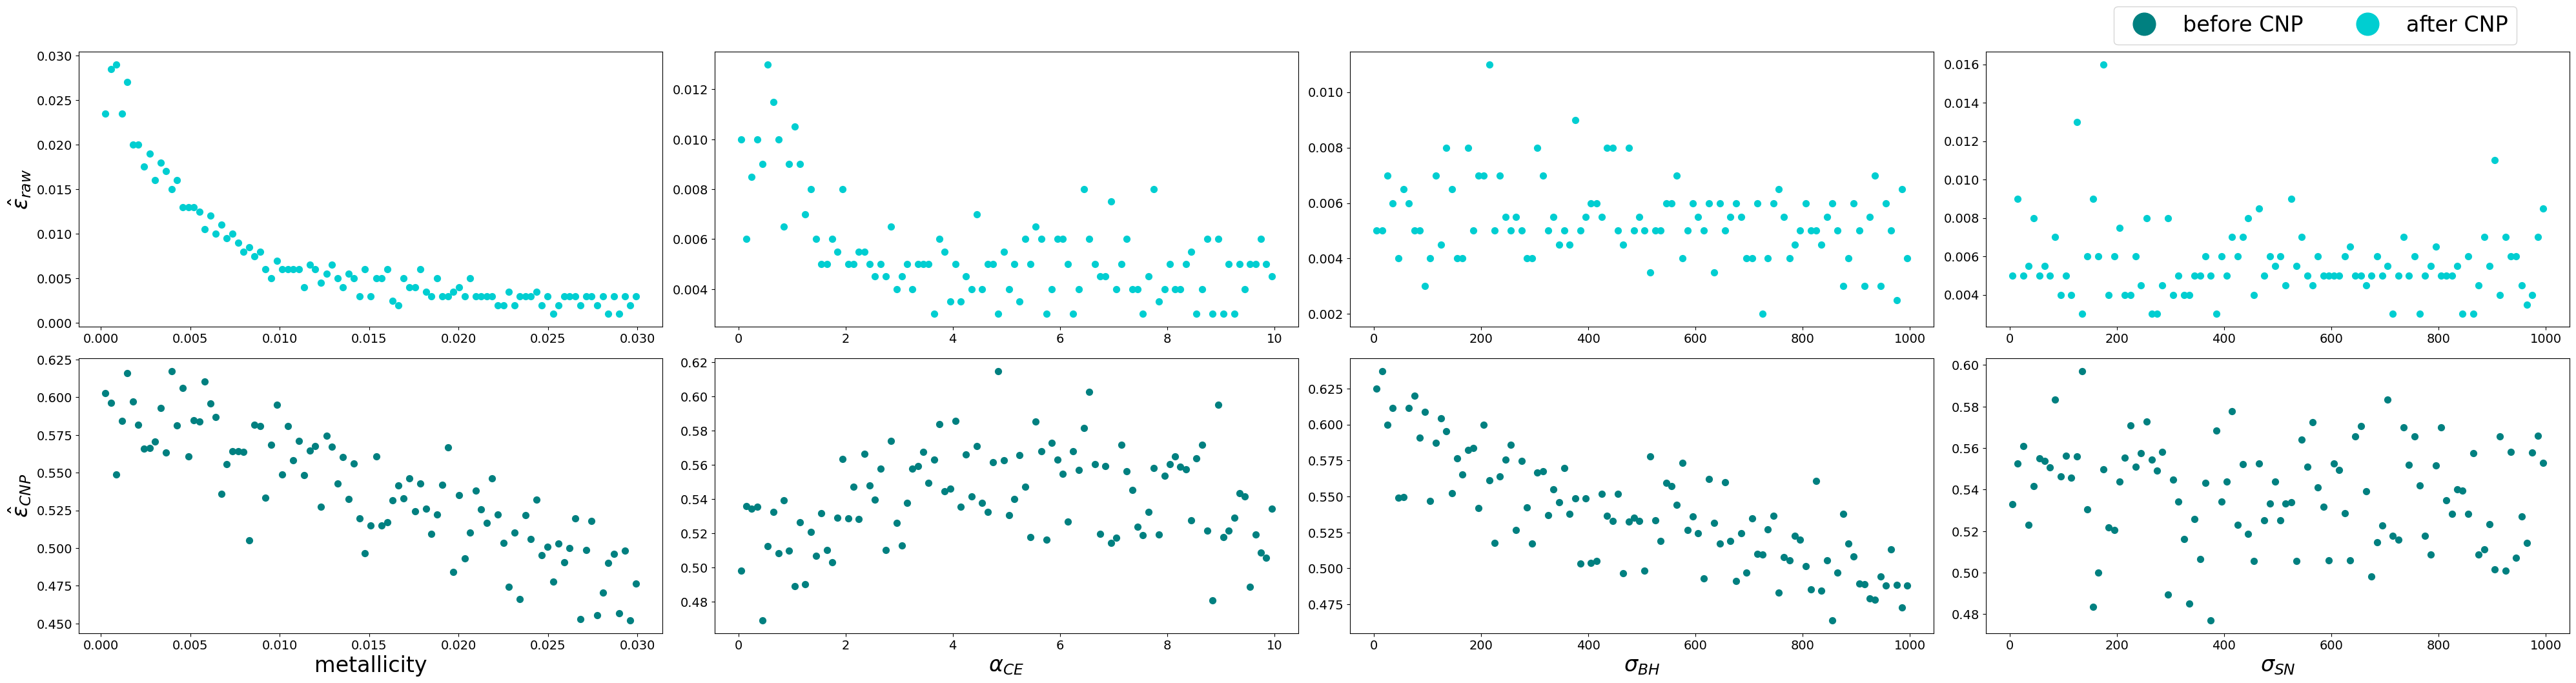

In [13]:
fig=get_marginialized_all(config_file=config_file, grid_steps=10)

fig.savefig(f'{path_out}/cnp_{version}_output.png')

#  Start TensorBoard

Run this in terminal:

tensorboard --logdir=\<path to tensor board log dir\> --host=0.0.0.0 --port=7007

Open:

http://localhost:7007/